# Implicit function toolbox for geophysics

If we can fit a point data to an Implicit Neural Network, we can operate directly on the Neural Network representation.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import random
from pathlib import Path

import comet_ml
import colorcet as cc
import harmonica
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import torch
import xarray as xr
from torch.utils.data import random_split

import geoinr.batcheddatasets
import geoinr.trainval
from geoinr.batcheddatasets import device, construct_xyz
from geoinr.batcheddatasets import BatchingDataloader, NCDataset, NoddyDataset
from geoinr.models import Siren
from geoinr.models import get_INR as wire
from geoinr.utils import (
    query_inr, query_inr_batched, plt_inr, plt_cntr, plt_3d,
    plt_sample_locs, plt_kwargs, e_size, load_nc_grid
    )


torch.manual_seed(seed := 0)
random.seed(seed)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

fig_out = Path("figures")
style = "./mpl_styles/paper.mplrc"
plt.style.use(style)

In [2]:
# file_path = Path(r"C:\Users\Public\scratch\Ch3\Ice_Cap.csv")
# dataset = geoinr.batcheddatasets.CSVDataset(
#     file_path, variable="MagF", usecols=("X", "Y", "Height_WGS84", "MagF")
# )
# dataset = dataset.subsample_wesnbt((-0.5, 0.6, -0.5, 0.5, -1, 1))
# train_dataset, val_dataset = random_split(dataset, [0.3, 0.7])
# print(f"{len(train_dataset)=}, {len(val_dataset)=}")


In [3]:
# Synthetic Data
shortname = "noddy"

noddy_path = Path("D:/luke/data_source/Forward_models_xyz/20-09-04-15-28-12-785467793")
dataset = NoddyDataset(noddy_path, "mag", file_limit=50)
dataset.subsample_wesnbt((-1, 1, -1, 1, -1, 1))

In [ ]:
# # P864 - Wolfe Creek
# shortname = "P864"
# # !wget "https://dapds00.nci.org.au/thredds/fileServer/iv65/Geoscience_Australia_Geophysics_Reference_Data_Collection/airborne_geophysics/WA/line/P864/P864-line-magnetic-AWAGS_MAG_2010.nc"
# netcdf_path = Path("C:/Users/public/scratch/Ch3/P864-line-magnetic-AWAGS_MAG_2010.nc")
# dataset = NCDataset(netcdf_path, variable="mag_microLevelled")
# dataset.xyz = dataset.xyz[:69700,:] # Drop tie lines at end of file
# dataset.u = dataset.u[:69700,:]
# terrain_clearance = 40 # Read dataset.ncd description
# gtt_path = Path("C:/Users/Public/scratch/Ch3/P864-grid-tmi.ers")

In [ ]:
# # P1260 Menzies North
# shortname = "P1260"
# terrain_clearance = 50
# # https://ecat.ga.gov.au/geonetwork/srv/eng/catalog.search#/metadata/143620
# # line: ! wget "https://dapds00.nci.org.au/thredds/fileServer/iv65/Geoscience_Australia_Geophysics_Reference_Data_Collection/airborne_geophysics/WA/line/P1260/P1260-line-magnetic-AWAGS_MAG_2010.nc"
# # grid: ! wget "https://dapds00.nci.org.au/thredds/fileServer/iv65/Geoscience_Australia_Geophysics_Reference_Data_Collection/airborne_geophysics/WA/grid/P1260/P1260-grid-tmi.nc"

# netcdf_path = Path("/home/luke/ImplicitGeo/data/Ch3/P1260/P1260-line-magnetic-AWAGS_MAG_2010.nc")
# dataset = geoinr.batcheddatasets.NCDataset(netcdf_path, variable="mag_microlevelled")
# ## Subsample full dataset (e.g. remove tie lines at end of file, or decimate)
# dataset.xyz = dataset.xyz[:12132381]
# dataset.u = dataset.u[:12132381]

# # Crop
# gtt_extent = b = [120.52, 120.57, -29.3, -29.25]
# dataset = dataset.subsample_wesnbt((
#               dataset.normalise(b[0], "e"), dataset.normalise(b[1], "e"),
#               dataset.normalise(b[2], "n"), dataset.normalise(b[3], "n"),
#              -1, 1,))

# # Load Reference Grid
# gtt, gtt_extent = load_nc_grid(
#     "/home/luke/ImplicitGeo/data/Ch3/P1260/P1260-grid-tmi.nc", crop=gtt_extent
#     )


In [4]:
train_dataset, val_dataset, test_dataset = random_split(dataset, [0.7, 0.2, 0.1])
print(f"{len(train_dataset) = }, {len(val_dataset) = }, {len(test_dataset) = } ")
print(f"Dropped {dataset.invalid_points} invalid points")

print("Mean Alt:", dataset.unnormalise(dataset.xyz[:, 2], "up").mean().item())
print("Std Alt:", dataset.unnormalise(dataset.xyz[:, 2], "up").std().item())


len(train_dataset) = 1400000, len(val_dataset) = 400000, len(test_dataset) = 200000 
Dropped 0 invalid points
Mean Alt: 590.0
Std Alt: 288.6174621582031


In [5]:
# dataset.ncd.variables.keys()
# np.arange(dataset.ncd.variables["lineType"][:].data)
# ((dataset.ncd.variables["line_index"][:]).data)

In [6]:
# plt_kwargs(f"{netcdf_path.stem}", {"extent":gtt_extent, "cmap":cc.cm.CET_L1}, Grid=gtt)

In [7]:
# dataset.plot_variables(
#     # ["mag_tieLevelled", "mag_microLevelled", "mag_awagsLevelled"], s=0.01
#     ["mag_microlevelled"], s=0.01
# )
# # "microlevelling removes low amplitude flight line noise after tie line levelling."
# dataset.plot_variables(["altitude"], s=0.01)

In [8]:
# Path("figures").mkdir(exist_ok=True)
# print(Path(f"figures/{shortname}_sample_locs").absolute())

In [9]:
# # %matplotlib widget

# fig = plt_sample_locs(
#     dataset,
#     label="Altitude (m)",
#     unnormalise_fn=dataset.unnormalise,
#     u=590,
#     # u=terrain_clearance,
# )  # u=terrain_clearance
# fig.savefig(f"figures/{shortname}_sample_locs")
# # %matplotlib inline


In [10]:
train_opts = dict(
    total_epochs=5000,  # 00,
    batch_size=1024_000,  # 2_048_000,  # 1M for 12 GB
    initial_lr=5e-5,
    scheduler="oclr",
    nonlinearity="sinusoidal",
    hidden_layers=8,
    hidden_features=256,
    weight_floss=0,  # .01, #4e-4,  # 1e-3, #1e-4,  # 1e-4,
    weight_rloss=0,  # 1e-3, #1e-4,  # 1e-4,
    rloss_Sigma=2e-6,  # norm width is 2
    n_samples=int(0.01 * dataset.u.shape[0]),  # 10% samples for RLoss
    wire_omega_0=10,
    wire_sigma=10,
    device="cuda",
    use_amp=False,
    # gt_tiff=tifffile.imread(gtt_path),
)

train_dataloader = BatchingDataloader(
    train_dataset,
    batch_size=train_opts["batch_size"],
    pin_memory=True,
)

val_dataloader = BatchingDataloader(
    val_dataset,
    batch_size=train_opts["batch_size"],
    pin_memory=True,
)

if train_opts["nonlinearity"] in ["sinusoidal", "siren"]:
    comet_tags = ["SIREN"]
    model = Siren(
        in_features=3,
        out_features=1,
        hidden_features=train_opts["hidden_features"],
        hidden_layers=train_opts["hidden_layers"],
        outermost_linear=True,
    )

elif "wire" in train_opts["nonlinearity"]:
    comet_tags = ["WIRE"]
    model = wire(
        nonlin=train_opts["nonlinearity"],  # "wire2d" | "wire3d"
        in_features=3,
        out_features=1,
        hidden_features=train_opts["hidden_features"],
        hidden_layers=train_opts["hidden_layers"],
        first_omega_0=train_opts["wire_omega_0"],  # first Frequency of sinusoid
        hidden_omega_0=train_opts["wire_omega_0"],  # hidden Frequency of sinusoid
        scale=train_opts["wire_sigma"],  # Sigma of Guassian
    )

f = model.to(device, non_blocking=True)

exp = geoinr.trainval.Exp(
    f,
    {"train": train_dataloader, "val": val_dataloader},
    train_opts,
)
inr = exp.train_inr()


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information
COMET INFO: Experiment is live on comet.ml https://www.comet.com/lukesmithgeo/geoinr/d1a102a436464d39af05e6e36df7f333



Training:   0%|          | 0/5000 [00:00<?, ?epoch/s]

COMET INFO: Uploading metrics, params, and assets to Comet before program termination (may take several seconds)
COMET INFO: The Python SDK has 3600 seconds to finish before aborting...
COMET INFO: Waiting for completion of the file uploads (may take several seconds)
COMET INFO: The Python SDK has 10800 seconds to finish before aborting...
COMET INFO: All files uploaded, waiting for confirmation they have been all received


Total steps: 10000


In [11]:
exp.exp.end()


In [ ]:
# loss_json = Path(
#     "/home/luke/ImplicitGeo/train_loss_mse_val_loss_mse_vs_step_chart_data.json"
# ).read_text()
# jtrain, jval, jtype, jname = json.loads(loss_json)
# # jtrain, jval = exp.loss_curves
# plt.figure(constrained_layout=True, figsize=(e_size("single"), e_size(60)), dpi=1000)
# # plt.title("Convergence")
# plt.yscale("log")
# plt.xlabel("Epoch")
# plt.ylabel("MSE")
# plt.plot(jtrain["x"], jtrain["y"], "-", linewidth=0.8, c="0.2", label="Train")
# plt.plot(jval["x"], jval["y"], "--", linewidth=0.8, c="0.3", label="Validation")
# plt.legend()
# plt.savefig("figures/loss_plot")


In [ ]:
# import rasterio
# with rasterio.open(gtt_path) as src:
#     gtt = src.read(1)
#     gtt_extent = src.bounds

In [56]:
normalise_fn = dataset.normalise
unnormalise_fn = dataset.unnormalise

# b = gtt_extent
b = [0, 4000, 0, 4000]
# shape = (gtt.shape[1], gtt.shape[0], 3)
# shape = (500, 500, 5)
shape = (200, 200, 3)
altitude = 200  # dataset.ncd.variables["altitude"][:].mean()
z_mod = normalise_fn(altitude, "up")
#altitude = unnormalise_fn(z_mod, "up")

extent = [
    unnormalise_fn(dataset.extent[0], "e"),
    unnormalise_fn(dataset.extent[1], "e"),
    unnormalise_fn(dataset.extent[2], "n"),
    unnormalise_fn(dataset.extent[3], "n"),
]

# ax_args = dict(cmap=cc.cm.CET_L1, vmin=-70, vmax=-55)
ax_args = dict(cmap=cc.cm.CET_L1)
z_vec = normalise_fn(torch.linspace(0, 200, steps=shape[2]), "up")

u = query_inr_batched(
    inr,
    shape=shape,
    chunksize=1_024_000,
    x_vec=normalise_fn(torch.linspace(b[0], b[1], steps=shape[0]), "e"),
    y_vec=normalise_fn(torch.linspace(b[2], b[3], steps=shape[1]), "n"),
    z_vec=z_vec,
    # z_mod=z_mod,
)

u = unnormalise_fn(u, "u")
std = u[1].std()


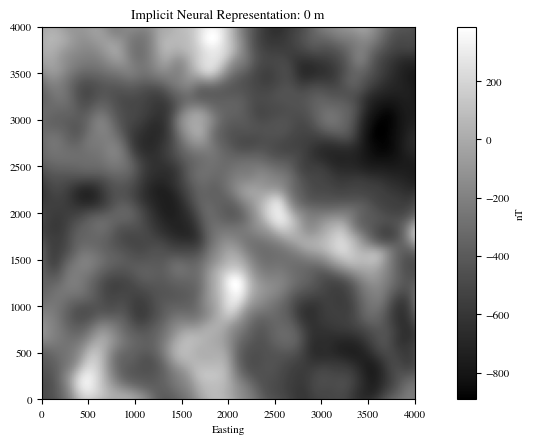

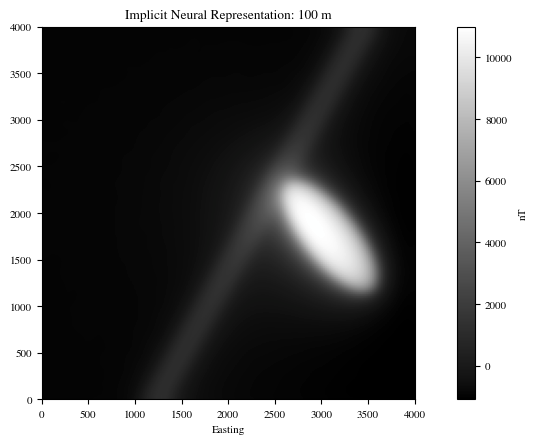

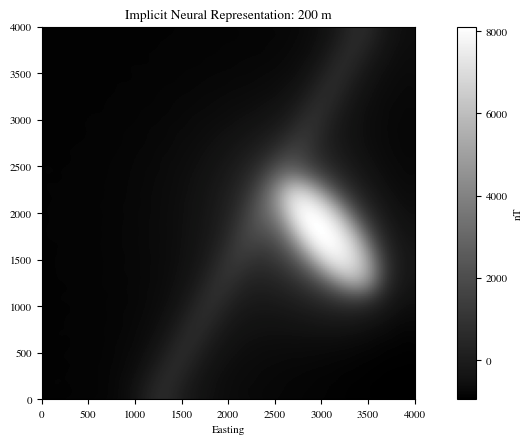

In [57]:
for i, z_slice in enumerate(u.transpose(2, 0, 1)):  # Iter through *zxy* slices
    altitude = unnormalise_fn(z_vec[i], "up")
    # print(altitude)
    fig = plt_inr(
        z_slice,
        extent=b,
        suffix=f": {int(altitude)} m",
        ax_args=ax_args,
        # _vmax=std,
        # _vmin=-std,
        # gt_grid=rio.open("/home/luke/ImplicitGeo/data/Ch3/wolfcreek_mag_microLevelled_bidir_30m.ers").read()[0,:,:], #,ref_grid,
        # gt_grid=gtt,
        cropping=(1, shape[1]),
        residual=False,
        figsize=(e_size("full"), e_size(110)),
        # dpi=1000,
    )
    plt.show()

    fig.savefig(fig_out / f"{shortname}_grid_comparison_{int(altitude)}m.png")


In [ ]:
# fig = plt_kwargs(
#     None, #"Grid comparison",
#     {"cmap": cc.cm.CET_L1, "vmin": -70, "vmax": -55, "extent": gtt_extent},
#     figsize=(e_size("full"), e_size(110)),
#     **{
#         "GA provided grid": gtt.read()[0],
#         "INR representation at 40 m": u.squeeze(),
#     }
# )

# fig.savefig(fig_out / f"grid_comparison_{}")


In [ ]:
# u = query_inr_batched(
#     inr,
#     shape=(200, 200, 5),
#     chunksize=1_000_000,
#     z_vec=normalise_fn(torch.linspace(30, 45, steps=200), "up"),
# )
# plt_3d(
#     unnormalise_fn(u, "up"),
#     ori="z",
#     levels=20,
#     step=51,
#     elezv=30,
#     azim=100,
#     linear_width=30,
#     alpha=0.1,
# )


In [ ]:
# # Noddyverse Synthetic Comparison
# plt_3d(
#     u=merge_z_slices(Path("/mnt/win_data/luke/data_source/Forward_models_xyz"), idx=1),
#     ori="z",
#     step=20,
#     elev=50,
#     azim=123,
#     linear_width=1000,
#     cmap=cc.cm.CET_L20,
#     alpha=0.5,
# )


## Gradients

So we've established that an Implicit function such as SIREN can learn a grid extent quite well.  
Now we want to calculate the gradients (Jacobian) using the network.  
We do this as a calculation of the gradients between the model inputs (x,y) and the model output (u) which is the TMI at that x,y point.

$$ U = f(x,y,z)\,,\, f:R^3 \to R^1 $$

U is the scalar magnetic field, $(x,y,z)$ (denoted $\phi$) are the three spatial dimensions, and
f is the function that defines the potential field by its coordinates.

In airborne geophysics, potential fields satisfy Laplace's equation:
$$\nabla^2 \phi = \frac{\partial^2\phi}{\partial x^2} + \frac{\partial^2\phi}{\partial y^2} + \frac{\partial^2\phi}{\partial z^2} = 0$$

Our Physics-informed Neural Network will be trained to respect Laplace's equation, using a regularisation term with an MSE objective toward 0.

To calculate the Laplacian in Pytorch, we have several tools. 

Laplacian, $ div \nabla $, or:
$$ \nabla^2 f(x,y,z) = \nabla \cdot \nabla f = (\frac{\partial^2{f}}{\partial{x^2}} + \frac{\partial^2{f}}{\partial{y^2}} + \frac{\partial^2{f}}{\partial{z^2}}) $$

There are several ways to calculate the Jacobian:  
1. `torch.autograd.grad` returns _the sum of gradients of outputs wrt inputs_.
1. `torch.autograd.functional.jacobian(vectorize=True)`
1. `functorch.jacrev`
1. `torch.trace(torch.func.hessian)`

Bear in mind that often Pytorch aims to calculate the gradient of a scalar loss fn wrt parameters. 
If the output is an arbitrary tensor, we require the Jacobian product.

https://github.com/pytorch/pytorch/issues/23475#issuecomment-946927242
https://pytorch.org/tutorials/beginner/introyt/autogradyt_tutorial.html#advanced-topic-more-autograd-detail-and-the-high-level-api, etc

We want the Jacobian of $f$: $$J_{f(x,y,z)} = [\frac{\partial{U(x,y,z)}}{\partial{x}}, \frac{\partial{U(x,y,z)}}{\partial{y}}, \frac{\partial{U(x,y,z)}}{\partial{z}}]$$


This is the special case where _the Jacobian matrix reduces to the row vector_, ${\displaystyle \nabla ^{\mathrm {T} }f}$

The row vector of all first-order partial derivatives of $f$ is the transpose of the gradient of $f$.
$${\displaystyle \mathbf {J} _{f}=\nabla ^{T}f}. $$



Gradient
$$\nabla {f(x,y,z)} =  (\frac{\partial{f}}{\partial{x}}, \frac{\partial{f}}{\partial{y}}, \frac{\partial{f}}{\partial{z}}) $$

Divergence: $ \nabla \cdot f$

Curl (0 for potential fields): $ \nabla \times f$

https://leimao.github.io/blog/PyTorch-Automatic-Differentiation/
https://najeebkhan.github.io/blog/VecCal.html



In [58]:
from geoinr.models import gradients, divergence, laplacian
from geoinr.models import PhysicsInform

vmap_gradients = PhysicsInform().vmap_gradients  # actually a batched Jacobian
vmap_laplacian = PhysicsInform().vmap_laplacian


In [39]:
### FROM SITZMANN:
def hessian(y, x):
    """hessian of y wrt x
    y: shape (meta_batch_size, num_observations, channels)
    x: shape (meta_batch_size, num_observations, 2)
    """
    meta_batch_size, num_observations = y.shape[:2]
    grad_y = torch.ones_like(y[..., 0]).to(y.device)
    h = torch.zeros(
        meta_batch_size, num_observations, y.shape[-1], x.shape[-1], x.shape[-1]
    ).to(y.device)
    for i in range(y.shape[-1]):
        # calculate dydx over batches for each feature value of y
        dydx = gradients(y[..., i], x, grad_y, create_graph=True)[0]

        # calculate hessian on y for each x value
        for j in range(x.shape[-1]):
            h[..., i, j, :] = gradients(dydx[..., j], x, grad_y, create_graph=True)[0][
                ..., :
            ]

    status = 0
    if torch.any(torch.isnan(h)):
        status = -1
    return h, status


def jacobian(y, x):
    """jacobian of y wrt x"""
    meta_batch_size, num_observations = y.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, y.shape[-1], x.shape[-1]).to(
        y.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(y.shape[-1]):
        # calculate dydx over batches for each feature value of y
        y_flat = y[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            y_flat, x, torch.ones_like(y_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status


def s_jacobian(u, xyz):
    """not sure where this is from: Jacobian of u wrt xyz"""
    meta_batch_size, num_observations = u.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, u.shape[-1], xyz.shape[-1]).to(
        u.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(u.shape[-1]):
        # calculate dydx over batches for each feature value of y
        u_flat = u[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            u_flat, xyz, torch.ones_like(u_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status


In [116]:
## Simple method for "Gradient", torch.autograd.grad
## The gradient is a special case of the Jacbian, when the function is scalar
## https://math.stackexchange.com/questions/1519367/difference-between-gradient-and-jacobian

shape = (200, 200, 1)
z_mod = normalise_fn(150, "up")
query_xyz = construct_xyz(shape, z_mod=z_mod)
query_xyz.requires_grad_(True)
query_xyz = query_xyz.to(device)

inr.return_coords = True
pred_u, query_xyz = inr(query_xyz)

pred_u = dataset.unnormalise(pred_u, var="u")
u = pred_u.detach().cpu().clone().view(shape).rot90().squeeze().numpy()

print("U     R  ", pred_u.shape)
print("x,y,z R^3", query_xyz.shape)

grad = gradients(pred_u, query_xyz)
# grad = [grad[0]]
# print(f"{grad[0].shape = }")


U     R   torch.Size([40000, 1])
x,y,z R^3 torch.Size([40000, 3])


d:\luke\Miniconda3\envs\bridging\Lib\site-packages\xrft\xrft.py:573: FutureWarning: Default ifft's behaviour (lag=None) changed! Default value of lag was zero (centered output coordinates) and is now set to transformed coordinate's attribute: 'direct_lag'.
  warnings.warn(msg, FutureWarning)


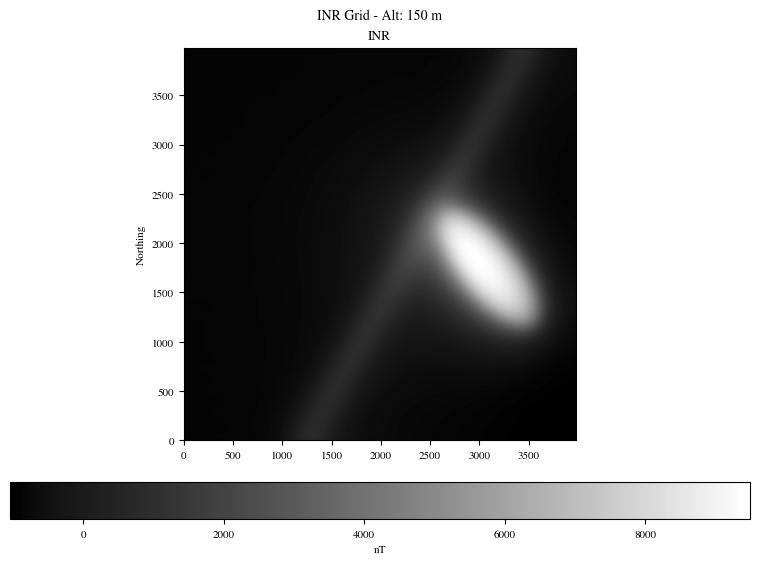

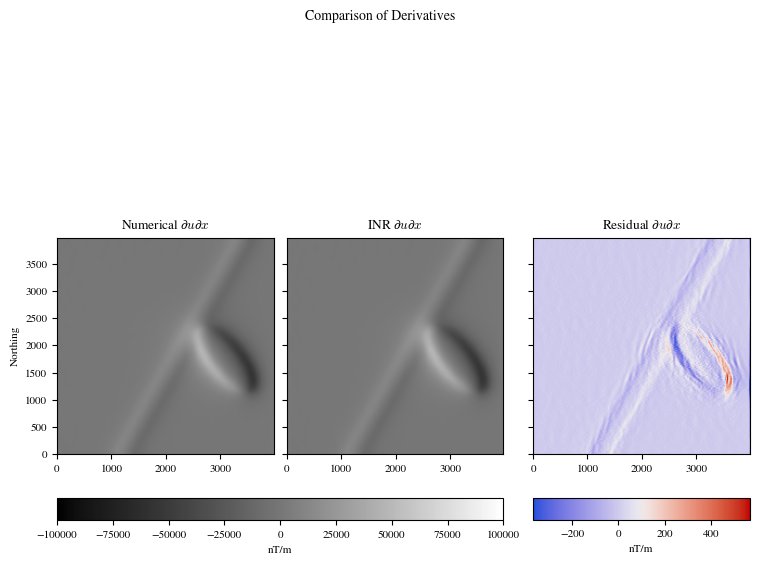

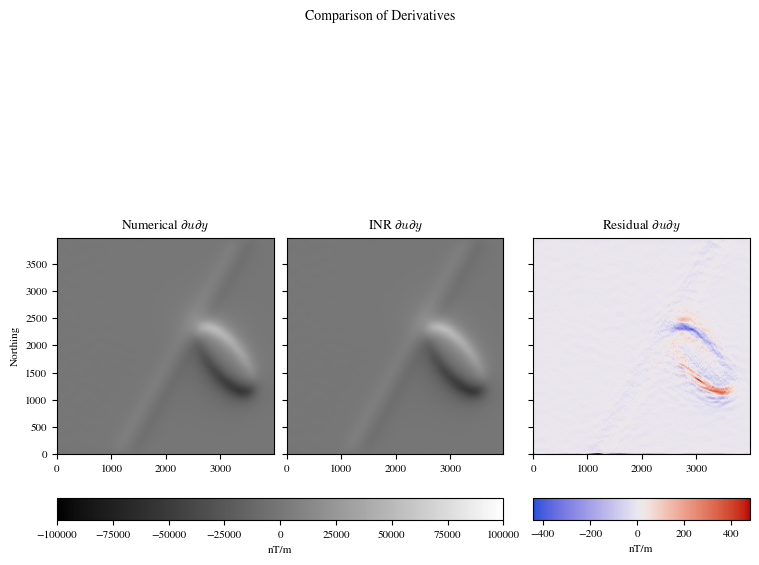

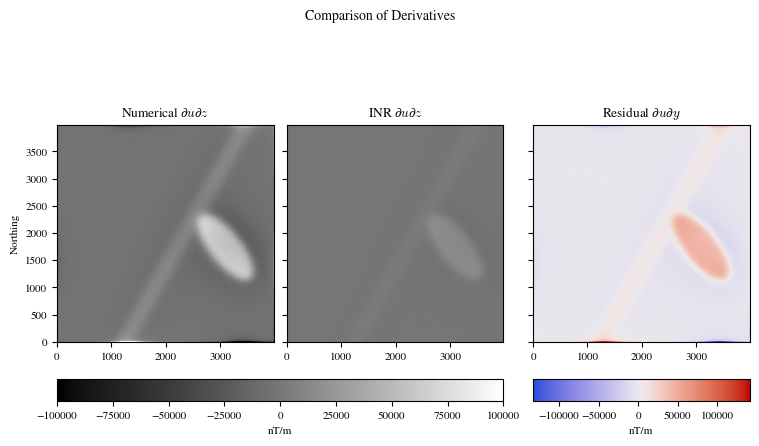

In [124]:
# First Derivative?
inr_dudx, inr_dudy, inr_dudz = grad.detach().cpu().squeeze().permute(1, 0)
inr_dudx = inr_dudx.view(shape[:2]).rot90().numpy()
inr_dudy = -inr_dudy.view(shape[:2]).rot90().numpy()  # NOTE Negative convention
inr_dudz = -inr_dudz.view(shape[:2]).rot90().numpy()

ax_args = dict(cmap=cc.cm.CET_L1, extent=extent, vmin=-100000, vmax=100000)

geo_u = xr.DataArray(
    u,
    coords={
        "northing": np.linspace(-1, 1, 200),
        "easting": np.linspace(-1, 1, 200),
    },
    dims=["northing", "easting"],
)
geo_dudx = harmonica.derivative_easting(geo_u)
geo_dudy = harmonica.derivative_northing(geo_u)
geo_dudz = harmonica.derivative_upward(geo_u)

# plt_kwargs(
#     "INR First Derivative",
#     ax_args,
#     # inr_dudz=inr_dudz,
# )

nstd = (
    3
    * np.maximum((geo_dudx - inr_dudx).std(), (geo_dudy - inr_dudy).std()).max().item()
)
nstd = None

fig = plt_kwargs(
    f"INR Grid - Alt: {unnormalise_fn(z_mod, 'up'):.0f} m",
    {**ax_args, **{"vmin": None, "vmax": None}},
    shape=(1, 1),
    **{
        "figsize": (e_size("full"), e_size(140)),
        "label": "nT",
        "INR": u,
    },
    # geo_dudz=geo_dudz,
)

fig = plt_kwargs(
    "Comparison of Derivatives",
    ax_args,
    shape=(1, 3),
    **{
        "figsize": (e_size("full"), e_size(140)),
        "label": "nT/m",
        "std": nstd,
        "Numerical $\partial{u}\partial{x}$": geo_dudx,
        "INR $\partial{u}\partial{x}$": inr_dudx,
        "Residual $\partial{u}\partial{x}$": (geo_dudx - inr_dudx),
    },
)
fig = plt_kwargs(
    "Comparison of Derivatives",
    ax_args,
    shape=(1, 3),
    **{
        "figsize": (e_size("full"), e_size(140)),
        "label": "nT/m",
        "std": nstd,
        "Numerical $\partial{u}\partial{y}$": geo_dudy,
        "INR $\partial{u}\partial{y}$": inr_dudy,
        "Residual $\partial{u}\partial{y}$": (geo_dudy - inr_dudy),
    },
    # geo_dudz=geo_dudz,
)

fig.savefig("figures/dh_comparison")

fig = plt_kwargs(
    "Comparison of Derivatives",
    ax_args,
    shape=(1, 3),
    **{
        "label": "nT/m",
        "figsize": (e_size("full"), e_size(110)),
        "std": nstd,
        # "figsize": (7.48, 3.73),
        "Numerical $\partial{u}\partial{z}$": geo_dudz,
        "INR $\partial{u}\partial{z}$": inr_dudz,
        "Residual $\partial{u}\partial{y}$": (geo_dudz - inr_dudz),
    },
)
fig.savefig("figures/dv_comparison")
# geo_dudz=geo_dudz,


# plt_kwargs(
#     r"Comparison First Derivative",
#     {"cmap": cc.cm.CET_L8, **{"vmax": 3}},
#     shape=(1, 3),
#     residual_dudz=np.sqrt((geo_dudz - inr_dudz) ** 2),
# )

In [70]:
print(np.square(geo_dudx - inr_dudx).mean())
print(np.square(geo_dudy - inr_dudy).mean())

print(((np.square(geo_dudx - inr_dudx).mean()) + (np.square(geo_dudy - inr_dudy).mean())) /2)

<xarray.DataArray ()>
array(7936.0576, dtype=float32)
<xarray.DataArray ()>
array(4645.629, dtype=float32)
<xarray.DataArray ()>
array(6290.84326172)


In [ ]:
import harmonica as hm
import xarray as xr
import xrft

import geoinr.datasets

shape = (500, 500, 1)
query_xyz = geoinr.datasets.construct_xyz(shape, z_mod=-0.4)
query_xyz.requires_grad_(True)
query_xyz = query_xyz.to(device)

inr.return_coords = True
pred_u, query_xyz = inr(query_xyz)

pred_u = unnormalise_fn(pred_u, var="u")
u = pred_u.detach().cpu().clone().view(shape).rot90().squeeze().numpy()

geo_u = xr.DataArray(
    u,
    coords={
        "northing": unnormalise_fn(np.linspace(-1, 1, 500), "n"),
        "easting": unnormalise_fn(np.linspace(-1, 1, 500), "e"),
    },
    dims=["northing", "easting"],
)

pad_width = {
    "easting": geo_u.easting.size // 3,
    "northing": geo_u.northing.size // 3,
}
# drop the extra height coordinate
magnetic_grid = xrft.pad(geo_u, pad_width)

upward_continued = hm.upward_continuation(magnetic_grid, height_displacement=5)
upward_continued = xrft.unpad(upward_continued, pad_width)




In [ ]:
plt_kwargs(
    "grids",
    {"cmap": cc.cm.CET_L1},
    # u=u,
    up_u=upward_continued,
)


In [ ]:
a_sig = torch.from_numpy(
    np.sqrt(
        (np.array(geo_dudx) ** 2)
        + (np.array(geo_dudy) ** 2)
        + (np.array(geo_dudz) ** 2)
    )
).view(shape[:2])

ax_args = dict(cmap=cc.cm.CET_R1, vmin=0, vmax=150)

fig = plt_kwargs(
    "Analytical Signal",
    ax_args,
    shape=(1, 1),
    **{
        "label": "nT",
        "figsize": (e_size("single"), e_size("single")),
        "Analytical Signal": a_sig,
    },
)


In [ ]:
inr_dudx, inr_dudy, inr_dudz = grad.detach().cpu().squeeze().permute(1, 0)
a_sig = (
    torch.sqrt((inr_dudx**2) + (inr_dudy**2) + (inr_dudz**2))
    .view(shape[:2])
    .rot90()
    .numpy()
)

fig = plt_kwargs(
    "Analytical Signal",
    ax_args,
    shape=(1, 1),
    **{"label": "nT", "figsize": (e_size("single"), e_size("single")), "Analytical Signal": a_sig},
)
fig.savefig("figures/asig")


In [ ]:
inr_dudx, inr_dudy, inr_dudz = grad.detach().cpu().squeeze().permute(1, 0)
tiltf = (
    torch.atan((inr_dudz**2) / ((inr_dudx**2) + (inr_dudy**2)))
    .view(shape[:2])
    .rot90()
    .numpy()
)
ax_args = dict(cmap=cc.cm.CET_R3)  # , vmin=0, vmax=150)

fig = plt_kwargs(
    "Tilt Filter",
    ax_args,
    shape=(1, 1),
    **{"label": "nT", "figsize": (7.48, 7.48), "Tilt Filter": tiltf},
)
# fig.savefig("figures/tiltf")


In [ ]:
# Second Derivative?
grad2 = torch.autograd.grad(
    outputs=[grad],
    inputs=[query_xyz],
    grad_outputs=torch.ones_like(grad),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
dxx, dyy, dzz = grad2[0].detach().cpu().squeeze().permute(1, 0)

plt_kwargs(
    "INR Second Derivative",
    ax_args,
    dudxx=dxx.view(shape[:2]).rot90().numpy(),
    dudyy=-dyy.view(shape[:2]).rot90().numpy(),
    dudzz=dzz.view(shape[:2]).rot90().numpy(),
)

u = xr.DataArray(
    u,
    coords=({"northing": np.linspace(-1, 1, 200), "easting": np.linspace(-1, 1, 200)}),
)
geo_d2dx2 = harmonica.derivative_easting(u, order=2)
geo_d2dy2 = harmonica.derivative_northing(u, order=2)
geo_d2dz2 = harmonica.derivative_upward(u, order=2)

plt_kwargs(
    "Geo Second Derivative",
    ax_args,
    geo_d2dx2=geo_d2dx2,
    geo_d2dy2=geo_d2dy2,
    geo_d2dz2=geo_d2dz2,
)

xmin = dudx.min()
xmax = dudx.max()
ymin = dudy.min()
ymax = dudy.max()

plt.figure(constrained_layout=True, figsize=(10, 10))
plt.subplot(221)
plt.title("Analytical dudx")
plt_cntr(dx)
plt.subplot(222)
plt.title("Implicit dudx")
plt.imshow(dudx, origin="lower", cmap=cc.cm.CET_L1, vmin=xmin, vmax=xmax)
plt.colorbar()
plt.subplot(223)
plt.title("Analytical dudy")
plt_cntr(dudy)
plt.subplot(224)
plt.title("Implicit dudy")
plt.imshow(dy, origin="lower", cmap=cc.cm.CET_L1, vmin=ymin, vmax=ymax)
plt.colorbar()


### Laplacian, etc

In [ ]:
pred_u = dataset.normalise(pred_u, "u")
laplacian(pred_u, query_xyz).squeeze()
pred_u = dataset.unnormalise(pred_u, "u")


In [ ]:
inr.return_coords = False
query_xyz = query_xyz.requires_grad_()
ft_jacobian = torch.func.vmap(
    torch.func.jacrev(
        inr,
        argnums=0,
        # chunk_size=2048,
        has_aux=bool(inr.return_coords),
    )
)(query_xyz)


In [ ]:
# grad = gradients(pred_u, query_xyz, order=1)
# dudx, dudy, dudz = grad.detach().cpu().squeeze().permute(1, 0)
# dudx

# grad2 = gradients(pred_u, query_xyz, order=2)
# d2udx2, d2udy2, d2udz2 = grad2.detach().cpu().squeeze().permute(1, 0)
# d2udx2


In [ ]:
# N = (10,3)
# f = inr
# x = torch.randn(N, requires_grad=True, device="cuda")
# y, x = inr(x)

# # vectorized gradient computation
# def get_vjp(v):
#     return torch.autograd.grad(y, x, v)
# jacobian = torch.vmap(get_vjp)(torch.ones_like(y))
# jacobian

# try 2

# torch.func.vmap(torch.func.hessian, in_dims=(None, 0))(lambda x: x**2)(torch.tensor([[1],[2],[3]], dtype=torch.float32))

# try 3
# def Smith_Hessian(u, f, xyz,):
#     batched_Laplacian = torch.func.hessian
#     return torch.func.vmap((batched_Laplacian), in_dims=)(f)(xyz)

# Smith_Hessian(None, inr, query_xyz)

# # def smithHessian(u, f, xyz):
# #     inr.return_
# #     hessian = torch.func.vmap(f)(xyz)

# #     return hessian


### Continuation

Eqn 12.2 from Blakely:
$$\frac{1}{4\pi} \iint_{-\infty}^{\infty} (\frac{1}{r} \frac{\partial U (x',y',z_{0})}{\partial z'} - U(x',y',z_{0}) \frac{\partial}{\partial z'} \frac{1}{r}) dx' dy'$$

Where $r = \sqrt{(x-x')+(y-y')+(z_{0} + \Delta z - z')^2}$

Note that eqn requires the vertical derivative $\frac{\partial U}{\partial z'}$ in addition to the value of U. 


The upward continuation integral, from Blakely (12.4) is shown in eqn.
$$U(x, y, z_{0}-\Delta z) = \frac{\Delta z}{2\pi} \iint_{-\infty}^{\infty} \frac{U(x', y', z_{0})}{[(x-x')^2 + (y-y')^2 + \Delta z^2]^\frac{3}{2}} dx'dy'$$

While options exist in the Fourier domain, we are keeping it spatial up in here.



# EXTRA

In [ ]:
# Explicit function: $$u(x,y,z) = \sin(x+y+z) + \cos(x-y-z)$$

# Explicit x, y, z partial derivatives:
# $$\frac{\partial{u(x,y,z)}}{\partial{x}} = \cos(x+y+z) - \sin(x-y-z)$$
# $$\frac{\partial{u(x,y,z)}}{\partial{y}} = \cos(x+y+z) + \sin(x-y-z)$$
# $$\frac{\partial{u(x,y,z)}}{\partial{z}} = \cos(x+y+z) + \sin(x-y-z)$$


In [ ]:
# ## Custom Function sample:
# # TODO make a custom geophysical test grid with just a box.
# def cust_f(d=200, a=1, l=1):
#     x, y, z = np.meshgrid(
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         indexing="xy",
#     )
#     u = a * (np.sin(x + y + z) + np.cos(x - y - z))
#     return (x, y, z, u)


# def cust_df(d=200, a=1, l=1):
#     x, y, z = np.meshgrid(
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         np.linspace(-l, l, d),
#         indexing="xy",
#     )
#     dudx = a * (np.cos(x + y + z) - np.sin(x - y - z))
#     dudy = a * (np.sin(x - y - z) + np.cos(x + y + z))
#     dudz = a * (np.sin(x - y - z) + np.cos(x + y + z))

#     return (dudx, dudy, dudz)


In [ ]:
# a = 1
# l = 4
# x, y, z, u = cust_f(d=200, a=a, l=l)
# dudx, dudy, dudz = cust_df(d=50, a=a, l=l)
# plt.imshow(u[25])
# # plt_3d(u, ori="z", step=50, elev=33, azim=120, linear_width=1, alpha=1)


In [ ]:
# opts = dict(ori="x", step=10, elev=45, azim=135, linear_width=1, cmap=cc.cm.CET_L1)

# fig = plt.figure(figsize=(30, 10), layout="constrained")
# ax = fig.add_subplot(131, projection="3d")
# plt_3d(dudx, **opts, ax=ax, fig=fig)
# ax = fig.add_subplot(132, projection="3d")
# plt_3d(dudy, **opts, ax=ax, fig=fig)
# ax = fig.add_subplot(133, projection="3d")
# plt_3d(dudz, **opts, ax=ax, fig=fig)
# # plt_3d(dudx, **opts, ax=fig.add_subplot(234, projection="3d"))
# # plt_3d(dudy, **opts, ax=fig.add_subplot(235, projection="3d"))
# # plt_3d(dudz, **opts, ax=fig.add_subplot(236, projection="3d"))


In [ ]:
# pred_u = dataset.normalise(pred_u, "u").clone().detach().requires_grad_()
# query_xyz = query_xyz.detach().clone().requires_grad_()

# torch.isclose(gradient(pred_u, query_xyz), ft_jacobian.squeeze())


In [ ]:
# No idea what this is doing, other than needing to return scalar
# def hvp(f, primals, tangents):
#   return torch.func.jvp(torch.func.grad(f.forward_return_vec), (primals,), (tangents,))[1]

# def hvp_revrev(f, primals, tangents):
#     _, vjp_fn = torch.func.vjp(torch.func.grad(f.forward_return_vec), *primals)
#     return vjp_fn(*tangents)

# inr.return_coords = False
# hvp(inr, query_xyz, torch.ones_like(query_xyz))


In [ ]:
inr.return_coords = False
pred_u = inr(query_xyz)
vmap_gradients(inr, query_xyz)


In [ ]:
%%timeit
pred_u = inr(query_xyz)
gradients(pred_u, query_xyz, 1)

In [ ]:
%%timeit
vmap_gradients(inr, query_xyz)

In [ ]:
torch.allclose(gradients(pred_u, query_xyz, 1), vmap_gradients(inr, query_xyz))


In [ ]:
inr.return_coords = False
query_xyz = query_xyz.requires_grad_()
ft_hessian = torch.func.vmap(
    torch.func.hessian(
        inr,
        argnums=0,
        # chunk_size=2048,
    ),
    in_dims=(None, 0),
)(query_xyz)
ft_hessian.shape


In [ ]:
ft_hessian.squeeze().shape


In [ ]:
torch.trace(ft_hessian.squeeze())


In [ ]:
compute_batch_jacobian = torch.func.vmap(
    torch.func.jacrev(inr, argnums=0), in_dims=(None, None, 0)
)
batch_jacobian0 = compute_batch_jacobian(weight, bias, x)


In [ ]:
smith_L = gradients(pred_u, query_xyz, order=2).sum(axis=0)
sitzm_L = laplace(pred_u, query_xyz)

plt_kwargs(
    "Laplacians",
    {"cmap": cc.cm.CET_D1, "vmin": -10000, "vmax": 10000},
    sitzm_L=sitzm_L.view(200, 200).detach().cpu().rot90().numpy(),
    smith_L=smith_L.view(200, 200).detach().cpu().rot90().numpy(),
)


## TODO

In [ ]:
def gradients(pred_u, xy_coord):
    """Compute the xx and yy gradients of the Implicit Function
    When trained, inputs of (x,y) coords to a Siren model (F) return u.
    Generally, this is u = F(x,y)
    """
    return (
        torch.autograd.grad(
            outputs=pred_u,
            inputs=[xy_coord],
            grad_outputs=torch.ones_like(pred_u),
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )[0]
        .detach()
        .reshape(dset.s, dset.s, 2)
        .permute(2, 0, 1)
        .cpu()
        # .numpy()
    )


# Below references are per Blakely, R. J. 1996
# _Potential Theory in Gravity and Magnetic Applications_
# Cambridge University Press


def horizontal_gradient(dudy, dudx):
    """Horizontal Gradient, eqn 12.49"""
    # return torch.sqrt(dudx ** 2 + dudy ** 2)
    return torch.dstack((dudy, dudx)).norm(dim=-1, p="fro")


def upward_continuation():
    """Upward Continuation, eqn 12.4
    It would be interesting to include u in the coords, and predict this
    """
    # (dz / 2 * pi) * double integral (output_xyz0) / ((x-x')^2 + (y-y')^2 + (dz**2))**(3/2) dxdy

    return NotImplementedError


def downward_continuation(du):
    """Downward Continuation, eqn 12.5
    args:
        - du: vertical distance to downward continue



    """

    return NotImplementedError


def vertical_derivative(order=1):
    """Vertical Derivative, eqn 12.17
    Args:
        order (int): Order of derivative, e.g. 2 for 2VD

    """
    return NotImplementedError


In [ ]:
pred_u, xy_coord = img_siren(model_input)
dudy, dudx = gradients(pred_u, model_input)
horiz_g = horizontal_gradient(dudy, dudx)


In [ ]:
plt.imshow(horiz_g, cmap=cc.cm.CET_L1, origin="lower")
plt.title("Horizontal Gradient")


In [ ]:
crop = dset.original_shape
# w,e,s,n = (0, crop[-2], 0, crop[-1])
w, e, s, n = zoom


In [ ]:
import matplotlib.colors as colors

fig, axs = plt.subplots(3, 2, layout="constrained", figsize=(10, 12))
plt.suptitle(f"Horizontal Derivatives - {sample.stem}")
plt_opts = dict(origin="upper", cmap=cc.cm.CET_L1)
[[axg, axp], [axx, axy], [axh, axoff]] = axs

axg.set_title(r"Original TMI Grid")
caxi = axg.imshow(
    dset.original_grid.squeeze()[s:n, w:e], cmap=cc.cm.CET_L1, origin="lower"
)
plt.colorbar(mappable=caxi, ax=axg, label=r"nT", location="bottom")

axp.set_title(r"Learnt TMI Grid")
caxp = axp.imshow(
    pred_u.detach().cpu().view(dset.s, dset.s).squeeze()[s:n, w:e], cmap=cc.cm.CET_L1
)
plt.colorbar(mappable=caxp, ax=axp, label=r"nT", location="bottom")

axh.set_title(r"Horizontal gradient")
caxh = axh.imshow(horiz_g[s:n, w:e], cmap=cc.cm.CET_L1, vmin=0, vmax=10)
plt.colorbar(mappable=caxh, ax=axh, label=r"nT/cell", location="bottom")

axx.set_title(r"$\delta$u$\delta$x")
caxx = axx.imshow(dudx[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxx, ax=axx, label=r"nT/cell", location="bottom")

axy.set_title(r"$\delta$u$\delta$y")
caxy = axy.imshow(dudy[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxy, ax=axy, label=r"nT/cell", location="bottom")

# norm = colors.LogNorm(vmin=0.1, vmax=60)
axoff.axis("off")

for ax in axs.ravel():
    ax.set_xlabel("x")
    ax.set_ylabel("y")


In [ ]:
# ## SPARE BITS###


# # from functorch import vmap, vjp, jacrev

# # vmap(jacrev(img_siren))(model_input)
# ###

# j = (dudx, dudy) = torch.autograd.functional.jacobian(lambda t: img_siren(t), model_input)#, vectorize=True)
# ###

# ## Sitzmann et al. method (non vectorised)
# meta_batch_size = pred_u.shape[0]  # only 1 tile
# num_observations = pred_u.shape[1]  # Num XYZ points,
# out_vecs = pred_u.shape[-1]  # num output channels, 1
# in_ch = xy_coord.shape[-1]  # num input channels, 2

# jac = torch.zeros(meta_batch_size, num_observations, out_vecs, in_ch).to(
#     pred_u.device
# )  # (meta_batch_size*num_points, 2, 2)
# for vec in range(out_vecs):
#     # calculate dydx over batches for each feature value of y
#     y_flat = pred_u[..., vec].view(-1, 1)
#     jac[:, :, vec, :] = torch.autograd.grad(
#         y_flat, xy_coord, torch.ones_like(y_flat), create_graph=True
#     )[0]

# ###

# jac2 = jac.squeeze().reshape(200,200,2).permute(2,0,1)[1]
# plt.imshow(jac2.detach().cpu().numpy())
# plt.colorbar()
# ###


# from functorch import vmap, vjp, jacrev

# def f(x):
#     return img_siren(x)

# j = jacrev(f)(model_input.squeeze())

# print(model_input.squeeze().shape)
# print(f"{j[0].shape=}")
# print(f"{j[1].shape=}")

# ###

# ## As of pytorch 1.13, we can now use functorch operations
# ## https://pytorch.org/functorch/stable/notebooks/jacobians_hessians.html

# # from functorch import vmap, vjp, jacfwd, jacrev
# # torch.manual_seed(0)

# # img_siren

# # m = model_input.clone().requires_grad_()

# # cotangents = torch.eye(m.shape[1])
# # _, vjp_fn = vjp((img_siren), m)
# # vmap(vjp_fn)(cotangents)

# # # ft_jacobian = jacrev(img_siren, argnums=(0,))(m)

# # # ft_jacobian = vmap(jacrev(img_siren, argnums = 0), in_dims=(None, 0, None))
# # # btach_jac = ft_jacobian( )

# # model_output, coords = img_siren(model_input)
# # print(f"{model_input.shape=}")
# # print(f"{img_siren(model_input)[0].shape=}")
# # print(f"{img_siren(model_input)[1].shape=}")

# # j = torch.autograd.functional.jacobian(lambda x: img_siren(x)[0], model_input, vectorize=True)
# # j2 = torch.diagonal(j, offset=0, dim1=0, dim2=2)
# # j3 = j2.permute(2,0,1)

# # j2.shape
# # j.squeeze()[1].reshape(s, s, 2).shape
